In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yaml

df  = pd.read_parquet("../data/processed/features.parquet")
cfg = yaml.safe_load(open("../config.yaml"))

fv = df["future_vol_60s"].dropna()
print(f"{len(fv):,} labelled ticks")

613,853 labelled ticks


In [2]:
# --- percentile table ---
rows = []
for p in [50, 75, 80, 85, 90, 95, 99]:
    t    = fv.quantile(p / 100)
    rate = (fv > t).mean() * 100
    move = t * 60_000          # approx $ move on a $60k BTC (σ × price)
    rows.append({"percentile": f"p{p}", "σ_future": round(t, 6),
                 "spike_rate": f"{rate:.1f}%", "≈$_move_1σ": f"${move:.2f}"})

pd.DataFrame(rows).set_index("percentile")

,σ_future,spike_rate,≈$_move_1σ
percentile,,,
p50,0.000031,50.0%,$1.88
p75,0.000041,25.0%,$2.46
p80,0.000044,20.0%,$2.61
p85,0.000047,15.0%,$2.81
p90,0.000051,10.0%,$3.08
p95,0.000059,5.0%,$3.52
p99,0.000077,1.0%,$4.65


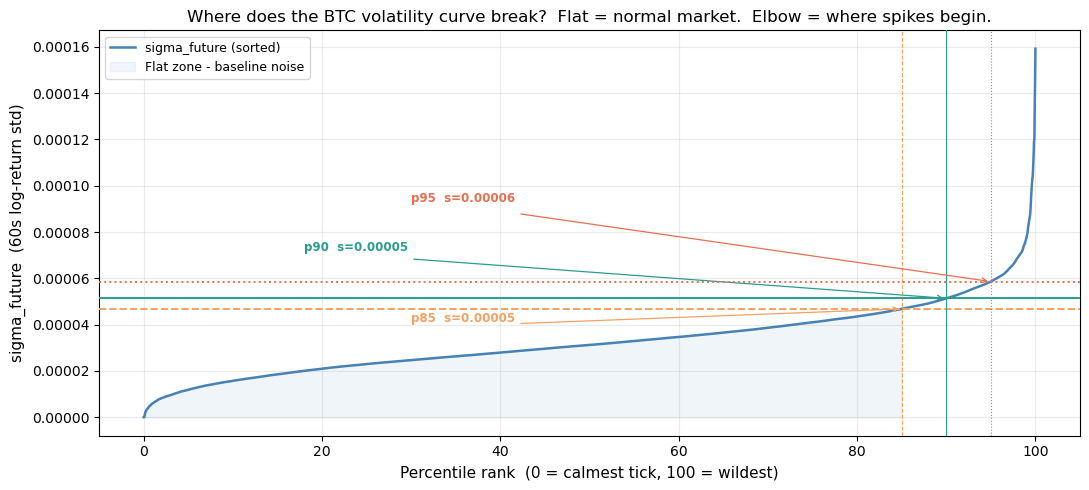

In [3]:
sorted_fv = np.sort(fv.values)
ranks     = np.linspace(0, 100, len(sorted_fv))

CANDIDATES    = {85: {"color": "#f4a261", "ls": "--"}, 90: {"color": "#2a9d8f", "ls": "-"}, 95: {"color": "#e76f51", "ls": ":"}}
LABEL_OFFSETS = {85: -0.000012, 90: 0.000014, 95: 0.000028}
LABEL_X       = {85: 30, 90: 18, 95: 30}

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ranks, sorted_fv, lw=1.8, color="steelblue", zorder=2, label="sigma_future (sorted)")
p85_val = fv.quantile(0.85)
ax.fill_between(ranks, sorted_fv, where=(sorted_fv <= p85_val), color="steelblue", alpha=0.08, label="Flat zone - baseline noise")

for p, style in CANDIDATES.items():
    val  = fv.quantile(p / 100)
    rate = (fv > val).mean() * 100
    ax.axhline(val, color=style["color"], lw=1.4, ls=style["ls"], zorder=3)
    ax.axvline(p,   color=style["color"], lw=0.8, ls=style["ls"], zorder=3)
    line1 = "p" + str(p) + "  s=" + format(val, ".5f")
    ax.annotate(line1 + chr(10), xy=(p, val),
                xytext=(LABEL_X[p], val + LABEL_OFFSETS[p]),
                fontsize=8.5, color=style["color"], fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=style["color"], lw=0.9))

ax.set_xlabel("Percentile rank  (0 = calmest tick, 100 = wildest)", fontsize=11)
ax.set_ylabel("sigma_future  (60s log-return std)", fontsize=11)
ax.set_title("Where does the BTC volatility curve break?  Flat = normal market.  Elbow = where spikes begin.", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.5f"))
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("../reports/eda_percentile_plot.png", dpi=150)
plt.show()


**Initial threshold choice:** τ = 0.000046 (P90) was selected as a starting point based on the percentile curve elbow.

**Updated after ablation:** The threshold sweep below (P85 / P90 / P95) showed that **P85 (τ = 0.000048)** yields the best validation PR-AUC and F1. The original P90 threshold is superseded — see the threshold sweep section for full results.

## Feature Correlation Analysis

Compute correlation matrix of all features vs `vol_spike`, identify highly correlated pairs (|r| > 0.85), and flag near-duplicates.

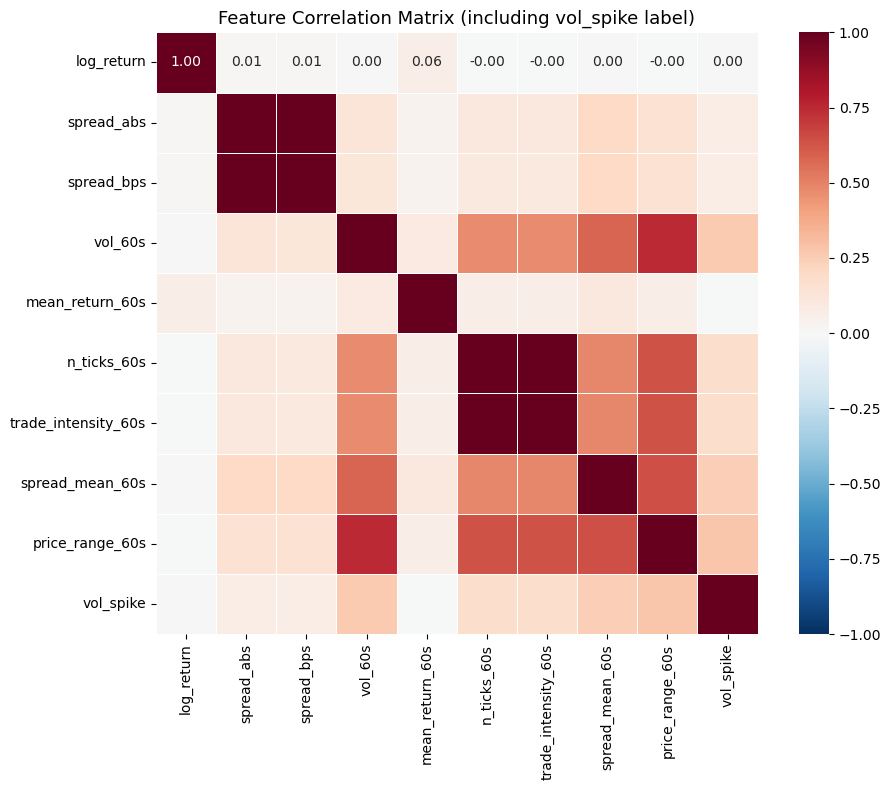

In [4]:
import seaborn as sns

FEATURE_COLS = [
    "log_return", "spread_abs", "spread_bps", "vol_60s",
    "mean_return_60s", "n_ticks_60s", "trade_intensity_60s",
    "spread_mean_60s", "price_range_60s",
]
TARGET = "vol_spike"

corr_cols = FEATURE_COLS + [TARGET]
corr = df[corr_cols].dropna().corr()

# --- heatmap ---
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix (including vol_spike label)", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/eda_correlation_matrix.png", dpi=150)
plt.show()

In [5]:
# --- correlation with vol_spike (sorted) ---
target_corr = corr[TARGET].drop(TARGET).sort_values(ascending=False)
print("Feature correlations with vol_spike:\n")
for feat, r in target_corr.items():
    print(f"  {feat:25s}  r = {r:+.4f}")

Feature correlations with vol_spike:

  price_range_60s            r = +0.2757
  vol_60s                    r = +0.2588
  spread_mean_60s            r = +0.2489
  n_ticks_60s                r = +0.1772
  trade_intensity_60s        r = +0.1772
  spread_abs                 r = +0.0780
  spread_bps                 r = +0.0777
  log_return                 r = +0.0014
  mean_return_60s            r = -0.0025


In [6]:
# --- highly correlated feature pairs (|r| > 0.85) ---
feature_corr = df[FEATURE_COLS].dropna().corr()

high_pairs = []
for i, f1 in enumerate(FEATURE_COLS):
    for f2 in FEATURE_COLS[i+1:]:
        r = feature_corr.loc[f1, f2]
        if abs(r) > 0.85:
            high_pairs.append((f1, f2, round(r, 4)))

if high_pairs:
    print("Highly correlated feature pairs (|r| > 0.85):\n")
    for f1, f2, r in sorted(high_pairs, key=lambda x: -abs(x[2])):
        print(f"  {f1:25s}  ↔  {f2:25s}  r = {r:+.4f}")
else:
    print("No feature pairs with |r| > 0.85 found.")

Highly correlated feature pairs (|r| > 0.85):

  n_ticks_60s                ↔  trade_intensity_60s        r = +1.0000
  spread_abs                 ↔  spread_bps                 r = +0.9999


## Feature Ablation Study

Structured ablation with 4 variants, all using the same LR hyperparameters (C=0.1, balanced, lbfgs). Threshold selected on validation best-F1. Winner picked on validation PR-AUC.

In [7]:
import json

ablation = json.load(open("../reports/ablation_results.json"))

rows = []
for v in ablation["variants"]:
    rows.append({
        "Variant": v["variant"],
        "#Feat": len(v["features"]),
        "tau": v["tau"],
        "val_PR-AUC": v["val_pr_auc"],
        "val_F1": v["val_f1"],
        "test_PR-AUC": v["test_pr_auc"],
        "test_F1": v["test_f1"],
        "test_P": v["test_precision"],
        "test_R": v["test_recall"],
    })

ablation_df = pd.DataFrame(rows).sort_values("val_PR-AUC", ascending=False)
ablation_df.style.highlight_max(subset=["val_PR-AUC"], color="#d4edda")

,Variant,#Feat,tau,val_PR-AUC,val_F1,test_PR-AUC,test_F1,test_P,test_R
1,B,7,0.724321,0.518200,0.528600,0.243600,0.295300,0.396200,0.235400
2,C,8,0.686995,0.503300,0.520700,0.249200,0.350100,0.328600,0.374700
3,D,7,0.686988,0.503300,0.520700,0.249200,0.350100,0.328600,0.374700
0,A,6,0.715606,0.499000,0.517500,0.237100,0.284200,0.348000,0.240100


### Ablation findings

- **Variant B wins** (val PR-AUC 0.5182): adding `spread_mean_60s` lifts performance over the 6-feature baseline.
- **Variants C and D are identical** in metrics, confirming that `spread_abs` and `n_ticks_60s` are redundant with other features (as predicted by the correlation analysis above).
- `price_range_60s` did not improve validation performance over B — slight drop from 0.5182 to 0.5033.
- The val-to-test PR-AUC gap (~0.27) is consistent across all variants, suggesting temporal distribution shift between splits rather than overfitting to a particular feature set.

**Decision:** Adopt Variant B (baseline + `spread_mean_60s`) as the production feature set.

## Threshold Sweep (P85 / P90 / P95)

Using the winning Variant B features, we swept the `vol_spike` label threshold across three percentiles of `future_vol_60s` to find the best label definition.

In [8]:
sweep = json.load(open("../reports/threshold_sweep_results.json"))

rows = []
for v in sweep["variants"]:
    gap = abs(v["val_pr_auc"] - v["test_pr_auc"])
    rows.append({
        "Percentile": v["percentile"],
        "sigma_thresh": v["vol_threshold"],
        "tau": v["tau"],
        "val_PR-AUC": v["val_pr_auc"],
        "val_F1": v["val_f1"],
        "val_spike%": f"{v['val_spike_rate']:.1%}",
        "test_PR-AUC": v["test_pr_auc"],
        "test_F1": v["test_f1"],
        "test_spike%": f"{v['test_spike_rate']:.1%}",
        "val-test gap": round(gap, 4),
    })

sweep_df = pd.DataFrame(rows)
sweep_df.style.highlight_max(subset=["val_PR-AUC"], color="#d4edda")

,Percentile,sigma_thresh,tau,val_PR-AUC,val_F1,val_spike%,test_PR-AUC,test_F1,test_spike%,val-test gap
0,P85,0.000048,0.712676,0.486300,0.518800,24.8%,0.210100,0.284100,8.3%,0.276200
1,P90,0.000052,0.714653,0.360400,0.453600,17.1%,0.129100,0.232900,5.1%,0.231300
2,P95,0.000059,0.702958,0.154400,0.279000,8.3%,0.062700,0.151600,2.4%,0.091700


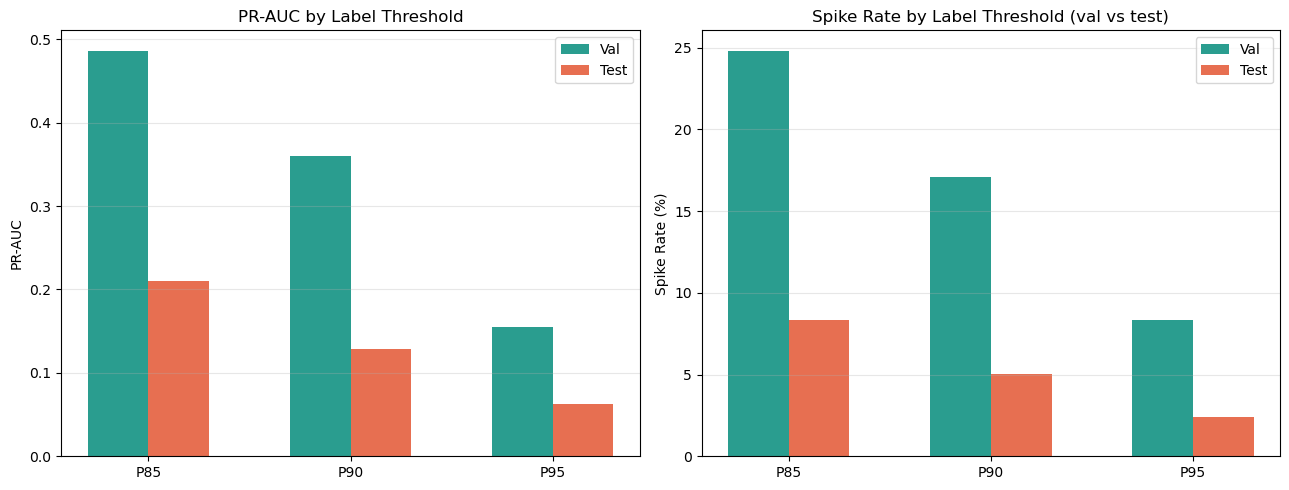

In [9]:
# Visualize val vs test PR-AUC across thresholds
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pctls = [v["percentile"] for v in sweep["variants"]]
val_aucs = [v["val_pr_auc"] for v in sweep["variants"]]
test_aucs = [v["test_pr_auc"] for v in sweep["variants"]]
val_f1s = [v["val_f1"] for v in sweep["variants"]]
test_f1s = [v["test_f1"] for v in sweep["variants"]]
val_spk = [v["val_spike_rate"] for v in sweep["variants"]]
test_spk = [v["test_spike_rate"] for v in sweep["variants"]]

x = np.arange(len(pctls))
w = 0.3

# PR-AUC comparison
axes[0].bar(x - w/2, val_aucs, w, label="Val", color="#2a9d8f")
axes[0].bar(x + w/2, test_aucs, w, label="Test", color="#e76f51")
axes[0].set_xticks(x)
axes[0].set_xticklabels(pctls)
axes[0].set_ylabel("PR-AUC")
axes[0].set_title("PR-AUC by Label Threshold")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Spike rate comparison
axes[1].bar(x - w/2, [s * 100 for s in val_spk], w, label="Val", color="#2a9d8f")
axes[1].bar(x + w/2, [s * 100 for s in test_spk], w, label="Test", color="#e76f51")
axes[1].set_xticks(x)
axes[1].set_xticklabels(pctls)
axes[1].set_ylabel("Spike Rate (%)")
axes[1].set_title("Spike Rate by Label Threshold (val vs test)")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/eda_threshold_sweep.png", dpi=150)
plt.show()

### Threshold sweep findings

| Percentile | val PR-AUC | val F1 | val spike% | test PR-AUC | test F1 | test spike% | val-test gap |
|------------|-----------|--------|-----------|------------|---------|-----------|-------------|
| **P85**    | **0.4863** | **0.5188** | 24.8% | 0.2101 | 0.2841 | 8.3% | 0.2762 |
| P90        | 0.3604 | 0.4536 | 17.1% | 0.1291 | 0.2329 | 5.1% | 0.2313 |
| P95        | 0.1544 | 0.2790 | 8.3% | 0.0627 | 0.1516 | 2.4% | 0.0917 |

**P85 wins** on both val PR-AUC (0.4863) and val F1 (0.5188).

Key observations:
- **Performance scales with spike rate:** P85 gives the model ~15% positive examples globally, enough signal to learn meaningful patterns. P95 (5%) starves the model.
- **The val-test gap is driven by temporal non-stationarity**, not model overfitting. The spike rate itself shifts dramatically between splits (val 24.8% vs test 8.3% at P85), reflecting genuine changes in market volatility regime across the data collection window.
- **P95 is most "stable"** (smallest gap: 0.0917) but only because both val and test performance are uniformly poor — stability at the cost of utility.

### Final model configuration

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Features | Variant B (7 features) | Best val PR-AUC in ablation; `spread_mean_60s` adds liquidity signal |
| Label threshold | P85 (sigma >= 0.000048) | Best val PR-AUC and F1 in threshold sweep |
| Classification tau | Selected on validation best-F1 | Avoids test-set leakage |